In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

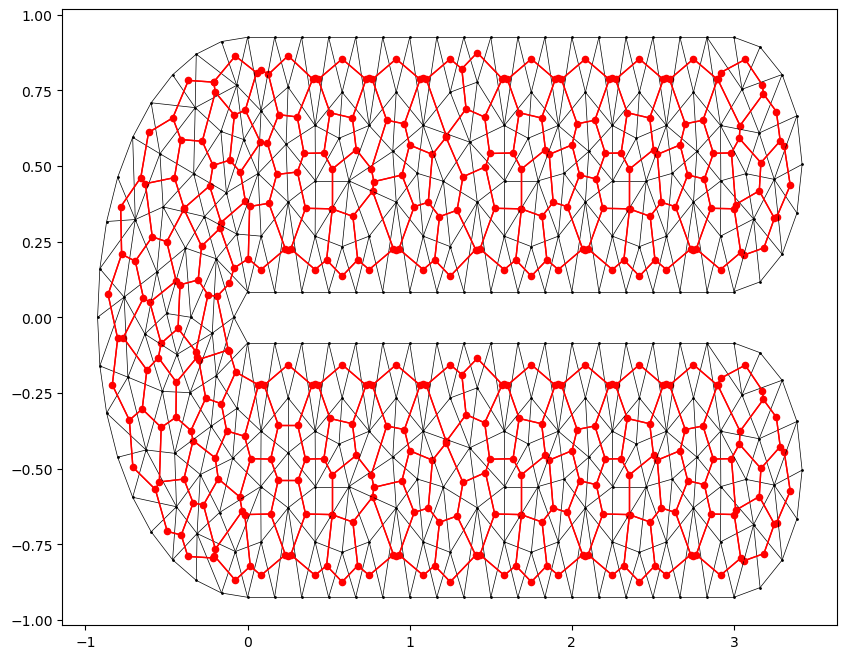

In [3]:
shape = "c_shaped"

def plot_voronoi(
    shape: str,
):
    df_points = pd.read_csv(f"../data/mesh/{shape}/points.csv").rename(columns={'Unnamed: 0': 'id'})

    _ = plt.figure(figsize=(10, 8))
    _ = plt.scatter(df_points['V1'], df_points['V2'], color='black', s=1)
    id2TriaNodes = {}
    for _, row in df_points.iterrows():
        id2TriaNodes[row['id']] = (row['V1'], row['V2'])

    df_edges = pd.read_csv(f"../data/mesh/{shape}/edges.csv").drop(columns='Unnamed: 0')
    triaEdges = []
    for _, row in df_edges.iterrows():
        triaEdges.append([id2TriaNodes[row['V1']], id2TriaNodes[row['V2']]])

    lc = LineCollection(triaEdges, colors='black', linewidths=0.5)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)

    with open(f"data/{shape}.json", 'r') as f:
        data = json.load(f)

    nodes = data['nodes']

    xs = [item['coords'][0] for item in nodes]
    ys = [item['coords'][1] for item in nodes]

    _ = plt.scatter(xs, ys, s=20, color='red')

    id2Node = {d['id']: (d['coords'][0], d['coords'][1]) for d in nodes}
    data
    edges = [[id2Node[d['from']], id2Node[d['to']]] for d in data['edges']]
    edges

    lc = LineCollection(edges, colors='red', linewidths=1)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)

    plt.show()

    return data

data = plot_voronoi(shape=shape)

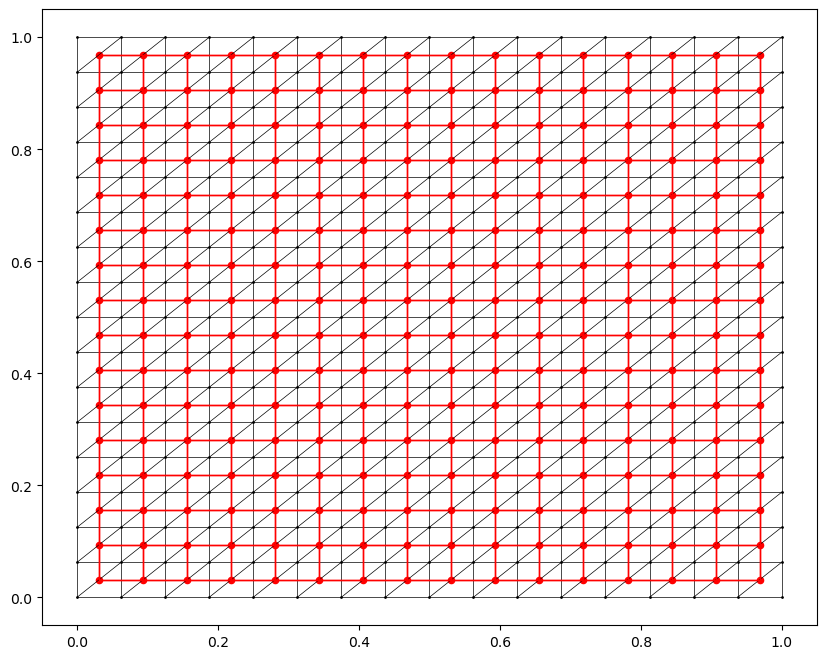

In [4]:
shape = "unit_square_16"
data = plot_voronoi(
    shape=shape
)

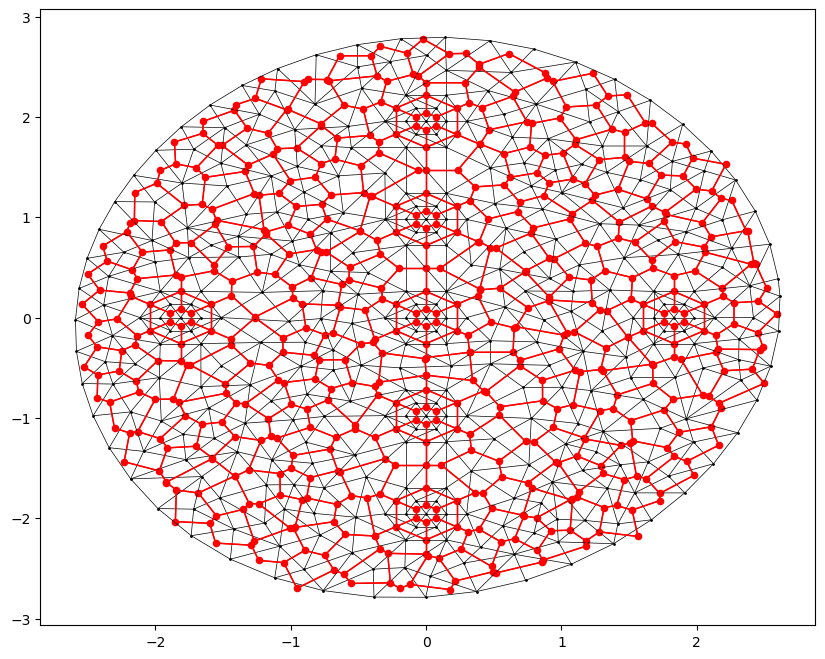

{'cells': [{'edges': [3, 43, 49], 'id': 24},
  {'edges': [4, 5, 13, 12, 7, 46], 'id': 241},
  {'edges': [6, 1], 'id': 25},
  {'edges': [8, 9, 37, 85, 124, 84, 48], 'id': 319},
  {'edges': [11, 35, 63, 42, 10], 'id': 320},
  {'edges': [15, 23, 18, 19, 53, 36, 14], 'id': 245},
  {'edges': [17, 27, 30, 31, 22], 'id': 99},
  {'edges': [21, 58, 59, 56, 20], 'id': 190},
  {'edges': [24, 25], 'id': 26},
  {'edges': [32, 33, 92, 93, 62, 57], 'id': 118},
  {'edges': [29, 71], 'id': 27},
  {'edges': [41, 70, 65, 40], 'id': 326},
  {'edges': [39, 104, 90, 38], 'id': 325},
  {'edges': [45, 47, 81, 108, 52, 44], 'id': 202},
  {'edges': [51, 105, 137], 'id': 23},
  {'edges': [54, 55, 98, 80, 74, 64], 'id': 321},
  {'edges': [60, 61, 126, 127, 178, 100, 97], 'id': 122},
  {'edges': [66, 67, 120, 115, 102, 103], 'id': 55},
  {'edges': [69, 73, 75, 68], 'id': 327},
  {'edges': [76, 77, 118, 119], 'id': 328},
  {'edges': [82, 83, 121, 112, 113], 'id': 82},
  {'edges': [89, 101, 136, 88], 'id': 324},
  {

In [5]:
shape = "quasi_circle"
plot_voronoi(
    shape=shape
)